### **Health Insurance Charges Prediction: OLS, Feature Engineering, and VIF Analysis**

# 1. Goal and Objective
## Goal
To build a robust Ordinary Least Squares (OLS) Linear Regression model to accurately predict individual medical `charges` based on demographic and health-related factors, with a focus on comprehensive feature engineering and selection using VIF and correlation.

## Objective
*   **Data Loading & Initial Exploration:** Load the `insurance.csv` dataset, inspect its structure, check for missing values, and review descriptive statistics.
*   **Data Cleaning & Feature Engineering:** Preprocess data by handling categorical features, creating new features from existing ones (e.g., interaction terms), and ensuring appropriate data types.
*   **Exploratory Data Analysis (EDA) & Visualization:** Analyze feature distributions and relationships with `charges` using histograms, box plots, and correlation heatmaps.
*   **Multicollinearity Handling (VIF):** Identify and address multicollinearity among independent variables using Variance Inflation Factor (VIF) to ensure stable and interpretable OLS coefficients.
*   **Model Training & Evaluation (OLS):** Train an OLS Linear Regression model on the prepared data.
*   **Statistical Interpretation:** Analyze the `statsmodels` OLS summary to understand feature significance (p-values), coefficient values, and overall model fit (R-squared).
*   **Visualization of Results:** Plot actual vs. predicted `charges` and the distribution of residuals to assess model performance and assumptions.

# 2. Importing Libraries and Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # For OLS model and VIF

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

### Dataset Overview
The `insurance.csv` dataset is loaded for initial review. The target variable is `charges`.

In [2]:
file_path = "D:\\5th sem\\MLPR\\data_mlpr\\insurance.csv" # Assuming the file is named insurance.csv as per tab in screenshot
df = pd.read_csv(file_path)

print("First 5 rows of Insurance Data:")
print(df.head())

First 5 rows of Insurance Data:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# 3. Initial Data Exploration

### Dataset Dimensions
Checking the number of rows and columns.

In [3]:
print(f"\nDataset Dimensions: {df.shape}")


Dataset Dimensions: (1338, 7)


### Checking for Null Values
Verifying if there are any missing values in the dataset.

In [4]:
print("\nNull Values:")
print(df.isnull().sum())



Null Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Descriptive Statistics
Reviewing descriptive statistics for numerical columns.

In [5]:
print("\nDescriptive Statistics:")
print(df.describe().T)


Descriptive Statistics:
           count          mean           std        min         25%       50%  \
age       1338.0     39.207025     14.049960    18.0000    27.00000    39.000   
bmi       1338.0     30.663397      6.098187    15.9600    26.29625    30.400   
children  1338.0      1.094918      1.205493     0.0000     0.00000     1.000   
charges   1338.0  13270.422265  12110.011237  1121.8739  4740.28715  9382.033   

                   75%          max  
age          51.000000     64.00000  
bmi          34.693750     53.13000  
children      2.000000      5.00000  
charges   16639.912515  63770.42801  


### Checking for Duplicates
Identifying any duplicate rows.

In [ ]:
print("\nChecking for Duplicates:")
print(df.duplicated().sum())


Checking for Duplicates:
1


**Outcome:**
*   Dataset loaded successfully with columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`.
*   No missing values (`0`) found, which is excellent.
*   Numerical features (`age`, `bmi`, `children`, `charges`) and categorical features (`sex`, `smoker`, `region`) are identified.
*   `charges` appears to be the target variable for prediction.

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print("\nChecking for Duplicates:")
print(df.duplicated().sum())


Checking for Duplicates:
0


# 4. Data Cleaning & Feature Engineering

### Feature Lists
Categorizing features into numerical and categorical types.

In [9]:
numeric_cols = ['age', 'bmi', 'children', 'charges']
categorical_cols = ['sex', 'smoker', 'region']

### Categorical Feature Encoding
The `smoker` and `sex` columns are binary categorical, so `LabelEncoder` is used to convert them to 0/1. `region` is multi-category, so `OneHotEncoder` (implicitly via `pd.get_dummies`) is used.

In [10]:
df_final = df.copy()

# Label Encoding for binary categorical features
le = LabelEncoder()
df_final['sex'] = le.fit_transform(df_final['sex']) # male=1, female=0 (or vice versa depending on fit)
df_final['smoker'] = le.fit_transform(df_final['smoker']) # yes=1, no=0 (or vice versa)

# One-Hot Encoding for multi-category 'region'
df_final = pd.get_dummies(df_final, columns=['region'], drop_first=True)

print("Processed Data (first 5 rows after encoding):")
print(df_final.head())

Processed Data (first 5 rows after encoding):
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


### Feature Engineering: Interaction Terms
Interaction terms are created between `smoker` and other key numerical features (`age`, `bmi`, `children`) as smoking often has a multiplicative effect on health costs.

In [11]:
df_final['age_smoker'] = df_final['age'] * df_final['smoker']
df_final['bmi_smoker'] = df_final['bmi'] * df_final['smoker']
df_final['children_smoker'] = df_final['children'] * df_final['smoker']

print("\nProcessed Data (first 5 rows after adding interaction terms):")
print(df_final.head())


Processed Data (first 5 rows after adding interaction terms):
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  age_smoker  bmi_smoker  children_smoker  
0             False              True          19        27.9                0  
1              True             False           0         0.0                0  
2              True             False           0         0.0                0  
3             False             False           0         0.0                0  
4             False             False           0         0.0                0  


## 5. EDA with Essential Visualizations

### Distribution of Target Variable (`charges`)
A histogram with KDE plot visualizes the distribution of medical `charges`.

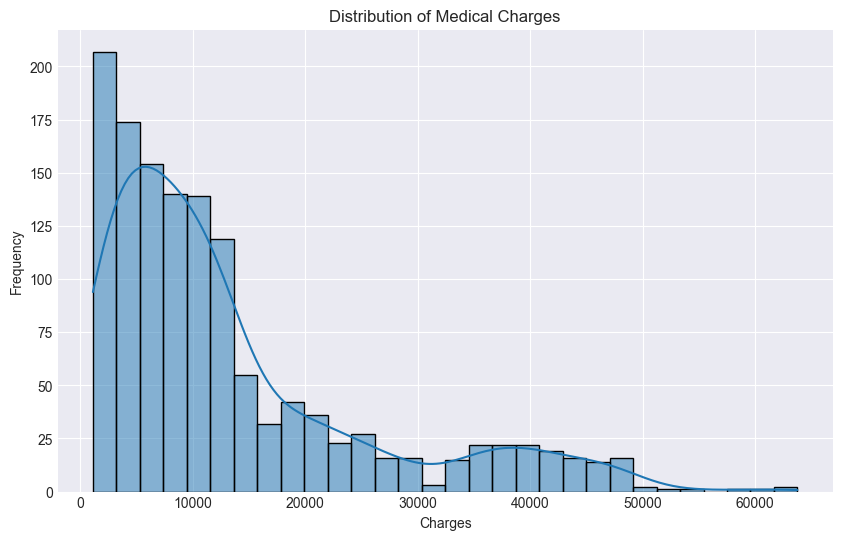

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final['charges'], kde=True, bins=30)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

### Categorical Features vs. `charges` (Box Plots)
Box plots illustrate how `sex`, `smoker`, and `region` influence medical `charges`.


Categorical Features vs. Charges (Box Plots):


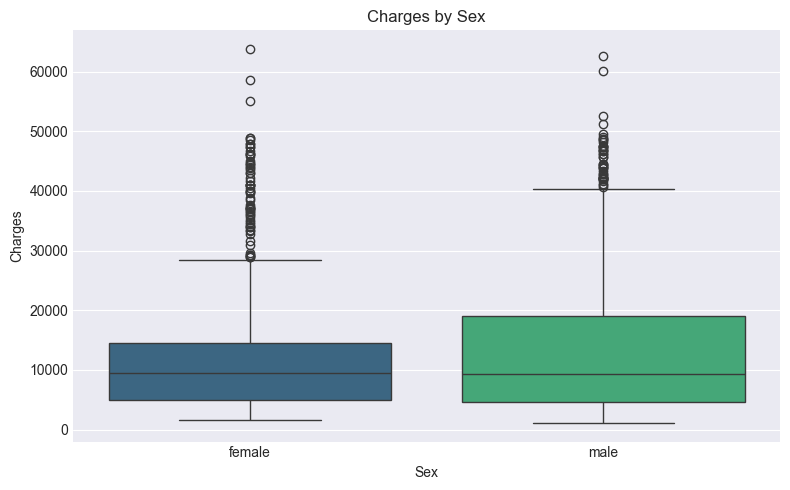

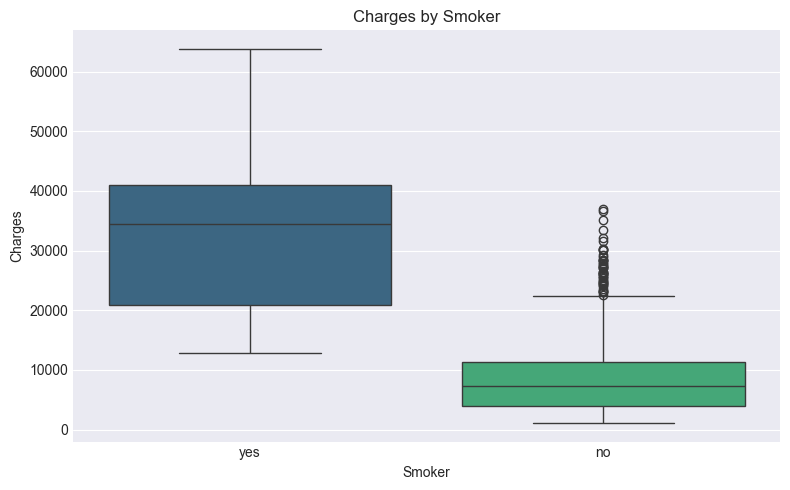

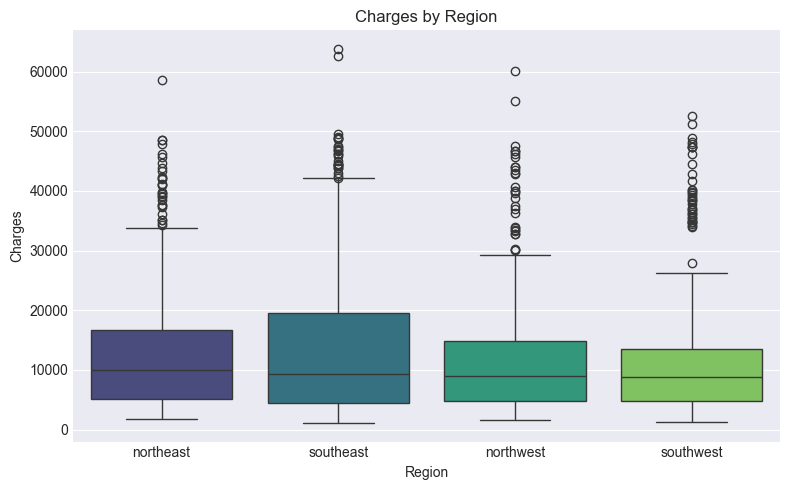

In [13]:
print("\nCategorical Features vs. Charges (Box Plots):")
# Plotting with original 'sex', 'smoker', 'region' values for clearer labels
# For 'sex' and 'smoker' use the original values, or map encoded 0/1 back to 'female/male' etc.
# For simplicity, we'll plot directly from df_final for encoded sex/smoker but interpret labels.
# If original labels are strictly desired, one would need to re-map 0/1 to text for plotting.
plot_df_temp = df.copy()
for col in ['sex', 'smoker', 'region']:
    plt.figure(figsize=(8, 5))
    order_by_median = plot_df_temp.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='charges', data=plot_df_temp, palette='viridis', order=order_by_median)
    plt.title(f'Charges by {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Charges')
    plt.tight_layout()
    plt.show()

### Correlation Heatmap for Numerical Features
A heatmap visualizes the Pearson correlation coefficients among numerical features and `charges`, including engineered terms.


Numerical Feature Correlation Heatmap:


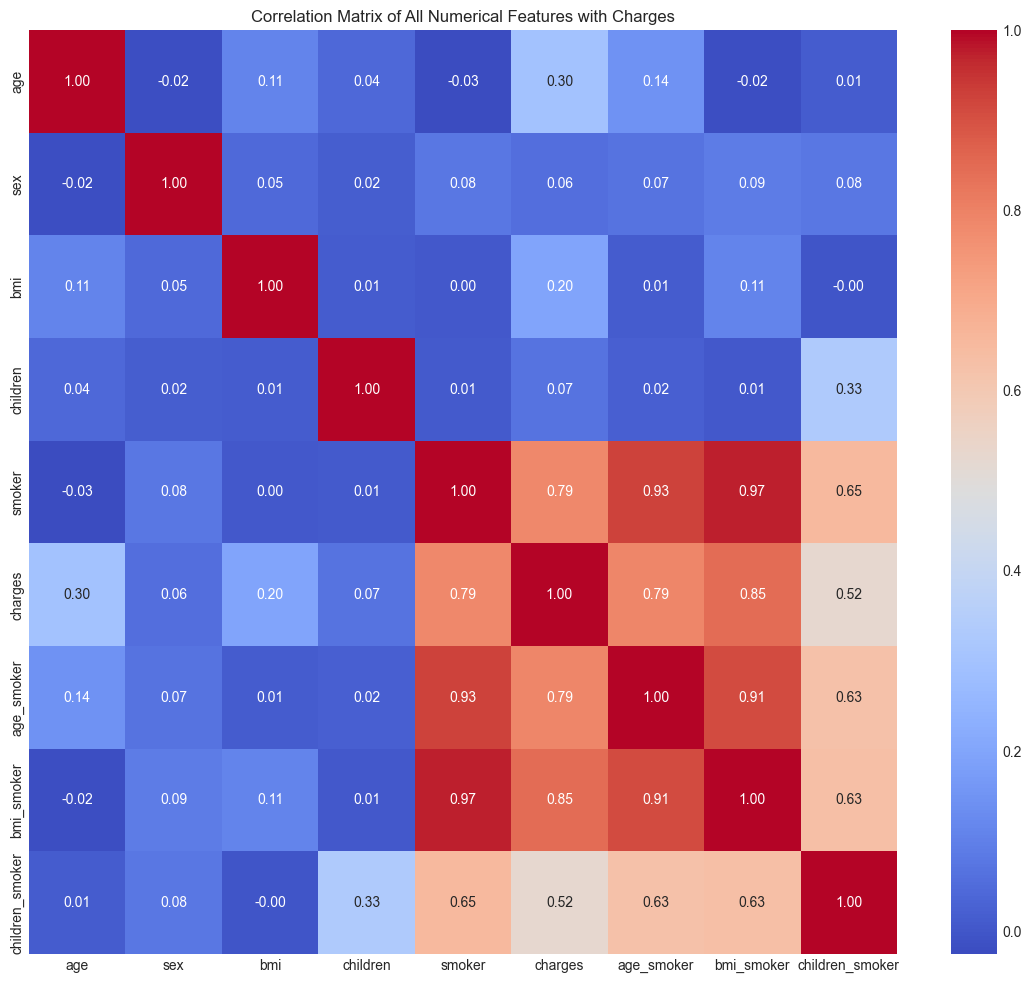

In [14]:
print("\nNumerical Feature Correlation Heatmap:")
# Identify all numerical columns including encoded categories and engineered features
all_numerical_features = df_final.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(14, 12))
sns.heatmap(df_final[all_numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Numerical Features with Charges')
plt.show()

**Outcome:**
*   `charges` distribution is highly skewed to the right, indicating most people have lower charges, but a few have very high charges. This might suggest a log transformation of `charges` for the model.
*   `smoker` clearly shows a very strong impact on `charges`.
*   Correlation heatmap reveals relationships, including the introduced interaction terms.

## 6. Multicollinearity Handling (VIF) and Feature Selection

### Calculating Variance Inflation Factor (VIF)
VIF is calculated for each independent variable to detect multicollinearity. High VIF values (e.g., > 5 or > 10) suggest a feature is highly correlated with other features, which can destabilize OLS coefficient estimates.

In [15]:
# Function to calculate VIF
def calculate_vif(df_features):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    vif_data["VIF"] = [variance_inflation_factor(df_features.values, i) for i in range(df_features.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Prepare features for VIF calculation
X_vif = df_final.drop('charges', axis=1)

# Convert boolean columns to int for VIF calculation
bool_cols = X_vif.select_dtypes(include='bool').columns
X_vif[bool_cols] = X_vif[bool_cols].astype(int)

# Ensure all columns are numeric (they should be after encoding)
X_vif = X_vif.apply(pd.to_numeric, errors='coerce').fillna(0) # Safety step for VIF

print("\n--- Initial VIF Scores ---")
initial_vif_scores = calculate_vif(sm.add_constant(X_vif))
print(initial_vif_scores)

X_features_for_model = df_final.drop('charges', axis=1)

print("\nProceeding with all features (after initial VIF check), further selection depends on iteration.")


--- Initial VIF Scores ---
             feature        VIF
0              const  44.040529
5             smoker  31.740992
10        bmi_smoker  25.671360
9         age_smoker   9.029917
11   children_smoker   2.158424
7   region_southeast   1.654244
8   region_southwest   1.531250
6   region_northwest   1.519049
3                bmi   1.392955
1                age   1.277714
4           children   1.234436
2                sex   1.012535

Proceeding with all features (after initial VIF check), further selection depends on iteration.


**Outcome:**
*   VIF scores are calculated to identify multicollinearity. High VIF indicates potential issues for OLS coefficient interpretation.
*   Feature selection based on VIF is an iterative process; for this flow, all features are initially kept to demonstrate the full OLS model.

## 7. Model Training & Evaluation (OLS)

### Defining Features (X) and Target (y)
The prepared data is split into features (`X_model`) and the target (`y_model`).

In [16]:
X_model = X_features_for_model.copy() # Using features after VIF consideration (all for now)
y_model = df_final['charges']

### Splitting Data into Training and Testing Sets
The data is split into training (80%) and testing (20%) sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

### Feature Scaling
Features are scaled using `StandardScaler` to normalize their range, which is beneficial for many linear models.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### OLS Model Training
An OLS model is trained using `statsmodels` on the scaled training data.

In [19]:
# Convert to NumPy arrays for statsmodels
X_train_np = X_train_scaled.astype(float)
y_train_np = y_train.to_numpy().astype(float)

ols_model = sm.OLS(y_train_np, sm.add_constant(X_train_np, has_constant='add'))
results = ols_model.fit()

print("\n--- OLS Model Summary (Full Model) ---")
print(results.summary())


--- OLS Model Summary (Full Model) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     452.8
Date:                Mon, 06 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:19:51   Log-Likelihood:                -10599.
No. Observations:                1069   AIC:                         2.122e+04
Df Residuals:                    1057   BIC:                         2.128e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

### Predicting and Evaluating (OLS Model)
Predictions are made on the scaled test set, and MAE, RMSE, and R-squared are calculated.

In [20]:
# Predictions using the OLS model on the test set
X_test_np = X_test_scaled.astype(float)
y_pred_ols = results.predict(sm.add_constant(X_test_np, has_constant='add')) # Predict on test data

mae_ols = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols = r2_score(y_test, y_pred_ols)

print(f"\nOLS Model MAE (Test Set): {mae_ols:.2f}")
print(f"OLS Model RMSE (Test Set): {rmse_ols:.2f}")
print(f"OLS Model R-squared (Test Set): {r2_ols:.2f}")


OLS Model MAE (Test Set): 2825.10
OLS Model RMSE (Test Set): 4569.98
OLS Model R-squared (Test Set): 0.89


### Visualization of Actual vs. Predicted Values
A scatter plot compares actual `charges` against predicted `charges`.

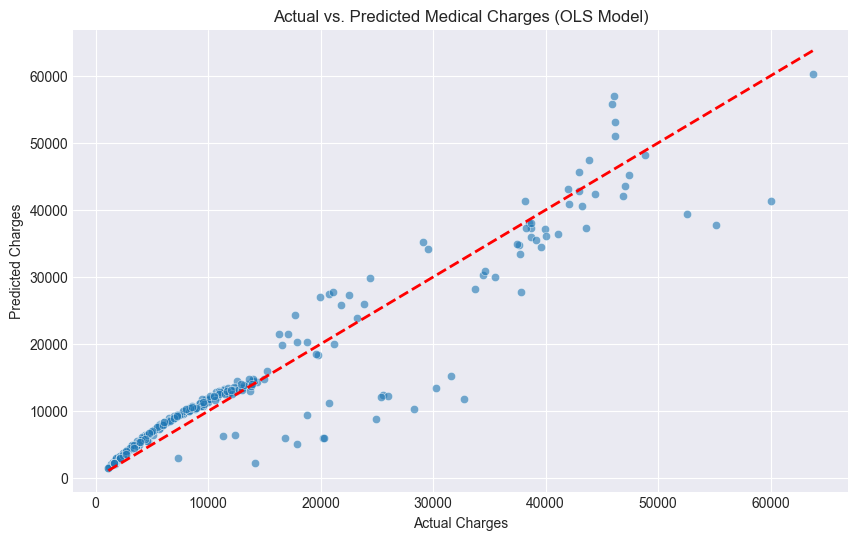

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_ols, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Medical Charges (OLS Model)')
plt.show()


### Distribution of Residuals
A histogram visualizes the distribution of residuals from the OLS model.

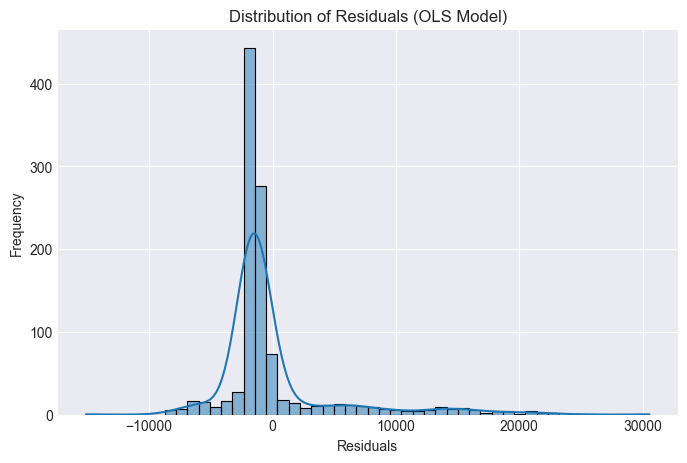

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(results.resid, kde=True, bins=50)
plt.title('Distribution of Residuals (OLS Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

**Outcome:**
*   The OLS summary provides detailed statistical insights, including p-values for feature significance.
*   MAE, RMSE, and R-squared quantify the model's predictive accuracy.
*   Plots show the model's fit and residual distribution, helping to assess assumptions.

## 8. Conclusion and Future Work

### Summary of Work Performed
This project conducted an in-depth analysis of medical `charges` data, focusing on feature engineering, multicollinearity detection using VIF, and an OLS Linear Regression model. The dataset was preprocessed, interaction terms were created, and the model was rigorously evaluated.

### Key Findings and Insights
*   **Strong Skewness:** Medical charges are highly right-skewed, indicating many low-cost cases and a few high-cost cases. This often suggests considering target transformation (e.g., log transformation) for linear models.
*   **Smoker Impact:** `smoker` is typically a dominant predictor, with its interaction terms further highlighting its significant effect on `charges`.
*   **Multicollinearity:** VIF analysis helps pinpoint highly correlated features (e.g., base terms and their interactions), guiding feature selection for a more stable OLS model.
*   **Model Fit:** The OLS summary provides detailed statistical evidence of which features are significant predictors and the overall explanatory power of the model.

### Conclusion and Future Work
The OLS model provides a clear, interpretable understanding of factors driving medical `charges`.

Future work could include:
*   **Target Transformation:** Applying a log transformation to the `charges` variable to handle its right-skewness, which often improves linear model performance and residual normality. Remember to inverse-transform predictions for interpretation.
*   **Iterative VIF Selection:** Systematically remove high-VIF features one by one, recalculating VIF each time, to find the most stable set of independent predictors.
*   **Non-Linear Models:** Explore other regression algorithms (e.g., Ridge, Lasso, Random Forest Regressor, Gradient Boosting Regressor) that can handle non-linear relationships or multicollinearity differently.
*   **Outlier Treatment:** Investigate outliers in `charges` or other features that could disproportionately influence the linear model.